# Estatísticas do artigo (essencial)

Backup: `7_stats.ipynb.bak_full`.

**Pergunta primary:** há alteração útil no tempo? → contraste **`t1_deltas` vs `t1_only`** (não `abs`/`wide`, não `deltas_rel`).

| Papel | Cohort | Encoding | Pasta | Uso |
|-------|--------|----------|-------|-----|
| **B · claim** | **`48m_12m`** | `t1_deltas` vs `t1_only` | `ablation_results_deltas/` vs `_t1_only/` | teste longitudinal (§4) |
| **B · gradiente** | 4 coortes ±2 | idem | idem | mapa gap×janela (§4c) |
| **B · gap curto** | `36m_6m` | idem | idem | controlo exploratório (§4b) |
| **A · âncora** | `36m_6m` (maior n) | `abs`/wide | `ablation_results/` | demografia, confound, abs vs t1, ComBat (§§1–3) |
| **A · clinic/leaky** | `48m_12m` (só aqui no disco) | abs + clinic | `_clinic*`, `_leaky` | §§5–6 |

Modelo fixed: `svm` · `l1_stable` · `combat=False`. Mods: `vol/shape/texture/disp` — sem `all` (ablações unimodais já cobrem o espaço; `all` é early-fusion, não modality separada no contraste B). Crowning pré-especificado claim B: **vol**; texture/shape = mapa.

| # | Pergunta | Papel |
|---|----------|-------|
| 1–2 | Demografia / confound idade-sexo | A · `36m_6m` |
| 3 / 3b | abs vs t1_only; ComBat | A · não é claim temporal |
| **4** | **t1_deltas vs t1_only em `48m_12m` (FDR)** | **B · teste principal** |
| 4b | mesmo contraste em `36m_6m` | B · gap curto |
| 4c | mesmo contraste × 4 coortes | B · gradiente |
| 5 | Clínico / imagem / fusão | A · `48m_12m` |
| 6 | abs vs leaky | A · `48m_12m` |

`PROTOCOL_LONGITUDINAL="t1_deltas"` ≠ `abs`. Não crownear `deltas_rel`.



In [1]:
from __future__ import annotations

import sys
from dataclasses import dataclass
from pathlib import Path

_MOD = Path.cwd() / "modules"
if str(_MOD) not in sys.path:
    sys.path.insert(0, str(_MOD))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy import stats
from sklearn.metrics import roc_auc_score

from ablation_analysis import (
    explode_patient_predictions,
    prepare_ablation_df,
)
from stats_compare import (
    apply_bh_fdr,
    clinical_results_path,
    compare_modalities,
    fusion_results_path,
    image_ablation_path,
    paired_comparison_row,
    print_comparison_summary,
)

# --- Cohorts: A = demografia/abs; B = claim longitudinal ---
COHORT_ANCHOR = "36m_6m"  # §§1–3 (maior n)
COHORT_CLAIM = "48m_12m"  # §4 primary + §§5–6 (clinic/leaky no disco)
COHORTS_GRADIENT = ("36m_6m", "36m_12m", "48m_6m", "48m_12m")

BASE = Path(f"csvs/cohorts/{COHORT_ANCHOR}")
BASE_CLAIM = Path(f"csvs/cohorts/{COHORT_CLAIM}")
LONG_CSV = BASE / "adnimerged_longitudinal.csv"
LONG_CSV_CLAIM = BASE_CLAIM / "adnimerged_longitudinal.csv"

MODS_COMPARE = ("vol", "shape", "texture", "disp")  # sem all: ablações já cobrem; all=early-fusion, não braço B
MOD_ANCHOR = "vol"  # crowning pré-especificado claim B
CLINIC_MODALITY = "shape"  # única clinic_img no disco (48m_12m)
FEATURE_MIN_COVERAGE = 50  # % folds com atributo (paper: top estáveis)

# Pastas ↔ representation (claim B = LONGITUDINAL vs BASELINE; NÃO deltas_rel)
PROTOCOL_ABS = "abs"  # wide T1+T2+T3 → ablation_results/
PROTOCOL_BASELINE = "t1_only"  # → ablation_results_t1_only/
PROTOCOL_LONGITUDINAL = "t1_deltas"  # → ablation_results_deltas/
REP_BY_PROTOCOL = {
    "abs": "wide",
    "t1_only": "t1_only",
    "t1_deltas": "t1_deltas",
    "deltas": "t1_deltas",  # alias legado
}


@dataclass(frozen=True)
class StatsCfg:
    task: str = "smci_pmci"
    groups: tuple[str, str] = ("sMCI", "pMCI")
    positive_group: str = "pMCI"
    modality: str = "vol"
    model_key: str = "svm"
    with_combat: bool = False
    selection_mode: str = "l1_stable"
    protocol: str = "abs"  # só âncora A (§§1–3); claim B usa PROTOCOL_*
    n_perm: int = 5000
    n_bootstrap: int = 5000
    seed: int = 42


ALPHA = 0.05  # limiar usual em artigos (5%)


def ler_p(p: float, *, contexto: str = "") -> str:
    """Texto curto para interpretar um p-value."""
    tag = "significativo" if p < ALPHA else "não significativo"
    acaso = "rejeitamos hipótese nula" if p < ALPHA else "compatível com acaso"
    prefix = f"{contexto}: " if contexto else ""
    return f"{prefix}{tag} (p={p:.4f}) — {acaso}"


STATS_CFG = StatsCfg()
print("Configuração atual:")
print(f"  âncora A:  {BASE}  (demografia / abs / ComBat)")
print(f"  claim B:   {BASE_CLAIM}  ({PROTOCOL_LONGITUDINAL} vs {PROTOCOL_BASELINE})")
print(f"  gradiente: {COHORTS_GRADIENT}")
print(f"  task={STATS_CFG.task}  grupos={STATS_CFG.groups}")
print(
    f"  modelo: {STATS_CFG.model_key}  selection={STATS_CFG.selection_mode}  "
    f"combat={STATS_CFG.with_combat}  mods={MODS_COMPARE}  crowning={MOD_ANCHOR}"
)
print(f"  clinic (§5): cohort={COHORT_CLAIM}  modality={CLINIC_MODALITY}")
print(f"  permutações={STATS_CFG.n_perm}  bootstrap={STATS_CFG.n_bootstrap}")



Configuração atual:
  âncora A:  csvs/cohorts/36m_6m  (demografia / abs / ComBat)
  claim B:   csvs/cohorts/48m_12m  (t1_deltas vs t1_only)
  gradiente: ('36m_6m', '36m_12m', '48m_6m', '48m_12m')
  task=smci_pmci  grupos=('sMCI', 'pMCI')
  modelo: svm  selection=l1_stable  combat=False  mods=('vol', 'shape', 'texture', 'disp')  crowning=vol
  clinic (§5): cohort=48m_12m  modality=shape
  permutações=5000  bootstrap=5000


In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


def load_cohort(long_path: Path, cfg: StatsCfg) -> pd.DataFrame:
    """Uma linha por paciente: slot baseline (legado) ou t0 (cohorts atuais)."""
    sub = pd.read_csv(long_path)
    slots = sub["slot"].astype(str)
    sub = sub[slots.isin(("baseline", "t0"))]
    sub = sub.sort_values(["ID_PT", "ID_IMG"]).groupby("ID_PT", as_index=False).first()
    sub = sub[sub["GROUP"].isin(cfg.groups)].copy()
    sub["ID_PT"] = sub["ID_PT"].astype(str)
    sub["y"] = (sub["GROUP"] == cfg.positive_group).astype(int)
    sub["SEX_bin"] = sub["SEX"].map({"M": 0, "F": 1, 0: 0, 1: 1})
    return sub


def permutation_auc_p(
    y: np.ndarray,
    scores: np.ndarray,
    *,
    n_perm: int,
    seed: int,
    bidirectional: bool = False,
) -> tuple[float, float]:
    y = np.asarray(y, dtype=int)
    s = np.asarray(scores, dtype=float)
    if bidirectional:
        auc_obs = float(max(roc_auc_score(y, s), roc_auc_score(y, -s)))
    else:
        auc_obs = float(roc_auc_score(y, s))
    prng = np.random.default_rng(seed)
    ge = 0
    for _ in range(n_perm):
        yp = prng.permutation(y)
        auc_n = max(roc_auc_score(yp, s), roc_auc_score(yp, -s)) if bidirectional else roc_auc_score(yp, s)
        ge += int(auc_n >= auc_obs)
    return auc_obs, (ge + 1) / (n_perm + 1)


def bootstrap_auc_diff(y, scores_a, scores_b, *, n_boot: int, seed: int) -> tuple[float, float, float]:
    y = np.asarray(y, dtype=int)
    a, b = np.asarray(scores_a, float), np.asarray(scores_b, float)
    obs = float(roc_auc_score(y, a) - roc_auc_score(y, b))
    prng = np.random.default_rng(seed)
    diffs = []
    for _ in range(n_boot):
        idx = prng.integers(0, len(y), size=len(y))
        yb, ab, bb = y[idx], a[idx], b[idx]
        if len(np.unique(yb)) < 2:
            continue
        diffs.append(float(roc_auc_score(yb, ab) - roc_auc_score(yb, bb)))
    diffs = np.asarray(diffs)
    ci_lo, ci_hi = np.percentile(diffs, [2.5, 97.5])
    return obs, float(ci_lo), float(ci_hi)


def bootstrap_auc_diff_test(
    y,
    scores_a,
    scores_b,
    *,
    n_boot: int,
    seed: int,
) -> tuple[float, float, float, float, float]:
    """ΔAUC = AUC(a)−AUC(b); IC95%; p one-sided (a>b) e two-sided."""
    y = np.asarray(y, dtype=int)
    a, b = np.asarray(scores_a, float), np.asarray(scores_b, float)
    obs = float(roc_auc_score(y, a) - roc_auc_score(y, b))
    prng = np.random.default_rng(seed)
    diffs = []
    for _ in range(n_boot):
        idx = prng.integers(0, len(y), size=len(y))
        yb, ab, bb = y[idx], a[idx], b[idx]
        if len(np.unique(yb)) < 2:
            continue
        diffs.append(float(roc_auc_score(yb, ab) - roc_auc_score(yb, bb)))
    diffs = np.asarray(diffs)
    ci_lo, ci_hi = np.percentile(diffs, [2.5, 97.5])
    p_one = float((np.sum(diffs <= 0) + 1) / (len(diffs) + 1))
    p_two = float(2 * min(p_one, 1 - p_one))
    return obs, float(ci_lo), float(ci_hi), p_one, p_two


def patient_scores_for_protocol(path: Path, cfg: StatsCfg) -> pd.DataFrame:
    return patient_image_scores(path, cfg).rename(columns={"score_img": "score"})


def nested_cv_auc_univariate(
    X: np.ndarray,
    y: np.ndarray,
    *,
    seed: int,
    k: int = 5,
) -> tuple[float, np.ndarray]:
    """LogReg + scaler em 1 atributo; AUC com predições out-of-fold."""
    X = np.asarray(X, dtype=float).reshape(-1, 1)
    y = np.asarray(y, dtype=int)
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=5000, random_state=seed)),
    ])
    cv = StratifiedKFold(k, shuffle=True, random_state=seed)
    scores = cross_val_predict(pipe, X, y, cv=cv, method="predict_proba")[:, 1]
    return float(roc_auc_score(y, scores)), scores


def patient_image_scores(
    path: Path,
    cfg: StatsCfg,
    *,
    expect_representation: str | None = None,
) -> pd.DataFrame:
    raw = prepare_ablation_df(pd.read_csv(path))
    mask = (
        (raw["task"] == cfg.task)
        & (raw["modality"] == cfg.modality)
        & (raw["model_key"] == cfg.model_key)
        & (raw["with_combat"] == cfg.with_combat)
        & (raw["selection_mode"] == cfg.selection_mode)
    )
    if expect_representation is not None and "representation" in raw.columns:
        mask = mask & (raw["representation"].astype(str) == expect_representation)
    sub = raw.loc[mask]
    if sub.empty:
        raise FileNotFoundError(
            f"sem linhas para {cfg}"
            + (f" representation={expect_representation}" if expect_representation else "")
            + f" em {path}"
        )
    if expect_representation is not None and "representation" in sub.columns:
        got = sorted(sub["representation"].astype(str).unique())
        if got != [expect_representation]:
            raise ValueError(f"representation inesperada em {path}: {got}")
    pat = explode_patient_predictions(sub)
    return pat.groupby("ID_PT", as_index=False).agg(y=("y", "first"), score_img=("score", "mean"))


def patient_scores_from_path(path: Path, cfg: StatsCfg) -> pd.DataFrame:
    """Infere representation esperada pela pasta do protocolo (deltas→t1_deltas)."""
    expect = None
    parts = {p.name for p in path.parents}
    if "ablation_results_deltas" in parts:
        expect = "t1_deltas"
    elif "ablation_results_t1_only" in parts:
        expect = "t1_only"
    elif "ablation_results" in parts and "ablation_results_deltas" not in parts:
        # pasta abs/wide; não confundir com *_deltas / *_t1_only (já cobertos acima)
        if not any(n.startswith("ablation_results_") for n in parts):
            expect = "wide"
    return patient_scores_for_protocol_expect(path, cfg, expect_representation=expect)


def patient_scores_for_protocol_expect(
    path: Path,
    cfg: StatsCfg,
    *,
    expect_representation: str | None,
) -> pd.DataFrame:
    return patient_image_scores(
        path, cfg, expect_representation=expect_representation
    ).rename(columns={"score_img": "score"})


def cfg_for_modality(
    mod: str,
    cfg: StatsCfg | None = None,
    *,
    with_combat: bool | None = None,
) -> StatsCfg:
    c = cfg or STATS_CFG
    return StatsCfg(
        task=c.task,
        groups=c.groups,
        positive_group=c.positive_group,
        modality=mod,
        model_key=c.model_key,
        with_combat=c.with_combat if with_combat is None else with_combat,
        selection_mode=c.selection_mode,
        protocol=c.protocol,
        n_perm=c.n_perm,
        n_bootstrap=c.n_bootstrap,
        seed=c.seed,
    )


def cfg_clinical(cfg: StatsCfg | None = None) -> StatsCfg:
    c = cfg or STATS_CFG
    return StatsCfg(
        task=c.task,
        groups=c.groups,
        positive_group=c.positive_group,
        modality="clinical",
        model_key=c.model_key,
        with_combat=False,
        selection_mode="none",
        protocol="clinical",
        n_perm=c.n_perm,
        n_bootstrap=c.n_bootstrap,
        seed=c.seed,
    )


cohort = load_cohort(LONG_CSV, STATS_CFG)
cohort_claim = load_cohort(LONG_CSV_CLAIM, STATS_CFG)
g0, g1 = STATS_CFG.groups
print(f"âncora A {BASE.name}: n={len(cohort)} | {cohort['GROUP'].value_counts().to_dict()}")
print(
    f"claim B  {BASE_CLAIM.name}: n={len(cohort_claim)} | "
    f"{cohort_claim['GROUP'].value_counts().to_dict()}"
)


def compare_deltas_vs_t1(
    base: Path,
    cfg: StatsCfg | None = None,
    *,
    comparison: str | None = None,
    modalities: tuple[str, ...] | None = None,
) -> pd.DataFrame:
    """Claim B: t1_deltas vs t1_only no cohort `base`."""
    c = cfg or STATS_CFG
    mods = modalities or MODS_COMPARE
    tag = comparison or f"{base.name}_t1_deltas_vs_t1_only"
    return compare_modalities(
        mods,
        path_a=lambda m: image_ablation_path(base, PROTOCOL_LONGITUDINAL, m),
        path_b=lambda m: image_ablation_path(base, PROTOCOL_BASELINE, m),
        cfg_for_mod=lambda m: cfg_for_modality(m, c),
        load_patients=patient_scores_from_path,
        permutation_auc_p=permutation_auc_p,
        n_perm=c.n_perm,
        n_bootstrap=c.n_bootstrap,
        seed=c.seed,
        label_a="t1_deltas",
        label_b="t1_only",
        comparison=tag,
        alpha=ALPHA,
    )


âncora A 36m_6m: n=231 | {'sMCI': 125, 'pMCI': 106}
claim B  48m_12m: n=120 | {'sMCI': 72, 'pMCI': 48}


## 1. Idade / sexo entre grupos (âncora A · `36m_6m`)


In [3]:
age_a = cohort.loc[cohort["GROUP"] == g0, "AGE"].dropna()
age_b = cohort.loc[cohort["GROUP"] == g1, "AGE"].dropna()
_, p_age_groups = stats.mannwhitneyu(age_a, age_b, alternative="two-sided")

sex_tab = pd.crosstab(cohort["GROUP"], cohort["SEX_bin"], rownames=["GROUP"], colnames=["SEX (0=M, 1=F)"])
_, p_sex_groups, _, _ = stats.chi2_contingency(sex_tab)

demo = pd.DataFrame([
    {
        "variável": "idade",
        "teste": "Mann-Whitney U",
        "grupo_a": g0,
        "valor_a": age_a.mean(),
        "o_que_e_valor": "média idade (anos)",
        "grupo_b": g1,
        "valor_b": age_b.mean(),
        "p": p_age_groups,
    },
    {
        "variável": "sexo",
        "teste": "χ²",
        "grupo_a": g0,
        "valor_a": cohort.loc[cohort["GROUP"] == g0, "SEX_bin"].mean(),
        "o_que_e_valor": "proporção mulheres (F=1)",
        "grupo_b": g1,
        "valor_b": cohort.loc[cohort["GROUP"] == g1, "SEX_bin"].mean(),
        "p": p_sex_groups,
    },
])

print("Tabela de contagens (entrada do χ²):")
display(sex_tab)
print("\nResumo (valores descritivos + p do teste):")
display(demo.round(4))

print("\n── Interpretação ──")
print(ler_p(p_age_groups, contexto="Idade"))
print(ler_p(p_sex_groups, contexto="Sexo"))
if p_age_groups >= ALPHA and p_sex_groups >= ALPHA:
    print("✓ Grupos demograficamente parecidos → idade/sexo entre classes pouco provável que confundam.")
else:
    print("⚠ Pelo menos uma variável difere → interpretar modelos da secção 2 com cautela.")

Tabela de contagens (entrada do χ²):


"SEX (0=M, 1=F)",0,1
GROUP,,
pMCI,56,50
sMCI,80,45



Resumo (valores descritivos + p do teste):


,variável,teste,grupo_a,valor_a,o_que_e_valor,grupo_b,valor_b,p
0,idade,Mann-Whitney U,sMCI,72.632,média idade (anos),pMCI,74.3868,0.0714
1,sexo,χ²,sMCI,0.360,proporção mulheres (F=1),pMCI,0.4717,0.1130



── Interpretação ──
Idade: não significativo (p=0.0714) — compatível com acaso
Sexo: não significativo (p=0.1130) — compatível com acaso
✓ Grupos demograficamente parecidos → idade/sexo entre classes pouco provável que confundam.


## 2. Idade ou sexo sozinhos discriminam? (âncora A)


In [4]:
cfg = STATS_CFG
pt = cohort[["ID_PT", "y", "AGE", "SEX_bin"]].dropna().copy()
y = pt["y"].to_numpy()

print("Passo A — modelo só com IDADE (nested CV + permutação)")
auc_age, scores_age = nested_cv_auc_univariate(pt["AGE"].to_numpy(), y, seed=cfg.seed)
_, p_age = permutation_auc_p(y, scores_age, n_perm=cfg.n_perm, seed=cfg.seed)
print(f"  AUC = {auc_age:.3f}  |  {ler_p(p_age)}")

print("\nPasso B — modelo só com SEXO")
auc_sex, scores_sex = nested_cv_auc_univariate(pt["SEX_bin"].to_numpy(), y, seed=cfg.seed + 1)
_, p_sex = permutation_auc_p(y, scores_sex, n_perm=cfg.n_perm, seed=cfg.seed + 1)
print(f"  AUC = {auc_sex:.3f}  |  {ler_p(p_sex)}")

pt = pt.assign(score_age=scores_age, score_sex=scores_sex)

print(f"\nPasso C — scores de IMAGEM ({cfg.protocol} / {cfg.modality})")
results_path = image_ablation_path(BASE, cfg.protocol, cfg.modality)
img = patient_image_scores(results_path, cfg).merge(pt, on=["ID_PT", "y"], how="inner")
y_m = img["y"].to_numpy()

auc_img, p_img = permutation_auc_p(
    y_m, img["score_img"].to_numpy(), n_perm=cfg.n_perm, seed=cfg.seed + 2,
)
print(f"  AUC = {auc_img:.3f}  |  {ler_p(p_img)}  |  n pacientes = {len(img)}")

print("\nPasso D — imagem melhor que demografia? (bootstrap do ΔAUC)")
d_age, ci_age_lo, ci_age_hi = bootstrap_auc_diff(
    y_m, img["score_img"].to_numpy(), img["score_age"].to_numpy(),
    n_boot=cfg.n_bootstrap, seed=cfg.seed + 3,
)
d_sex, ci_sex_lo, ci_sex_hi = bootstrap_auc_diff(
    y_m, img["score_img"].to_numpy(), img["score_sex"].to_numpy(),
    n_boot=cfg.n_bootstrap, seed=cfg.seed + 4,
)
print(f"  ΔAUC (imagem − idade) = {d_age:.3f}  IC95% [{ci_age_lo:.3f}, {ci_age_hi:.3f}]")
print(f"  ΔAUC (imagem − sexo)  = {d_sex:.3f}  IC95% [{ci_sex_lo:.3f}, {ci_sex_hi:.3f}]")

summary = pd.DataFrame([
    {"modelo": "só idade", "features": "AGE", "auc": auc_age, "p_permutation": p_age},
    {"modelo": "só sexo", "features": "SEX_bin", "auc": auc_sex, "p_permutation": p_sex},
    {"modelo": f"imagem ({cfg.protocol})", "features": cfg.modality, "auc": auc_img, "p_permutation": p_img},
    {"modelo": "imagem − idade", "features": "ΔAUC", "auc": d_age, "p_permutation": np.nan},
    {"modelo": "imagem − sexo", "features": "ΔAUC", "auc": d_sex, "p_permutation": np.nan},
])
summary["ci95"] = ["", "", "", f"[{ci_age_lo:.3f}, {ci_age_hi:.3f}]", f"[{ci_sex_lo:.3f}, {ci_sex_hi:.3f}]"]
summary["confunde"] = [
    bool(auc_age > 0.55 and p_age < ALPHA),
    bool(auc_sex > 0.55 and p_sex < ALPHA),
    False,
    np.nan,
    np.nan,
]
summary["imagem_superior"] = [np.nan, np.nan, np.nan, ci_age_lo > 0, ci_sex_lo > 0]

print("\n── Tabela resumo ──")
display(summary.round(4))

print("\n── Conclusão automática ──")
if not summary.loc[0, "confunde"] and not summary.loc[1, "confunde"]:
    print("• Idade e sexo **não** separam bem as classes → pouco risco de confusão demográfica.")
else:
    print("• Atenção: idade ou sexo mostram sinal discriminativo → interpretar imagem com cuidado.")

if p_img < ALPHA and auc_img > 0.55:
    print(f"• Imagem ({cfg.protocol}) discrimina significativamente (AUC ≈ {auc_img:.2f}).")
if ci_age_lo > 0:
    print(f"• Imagem supera idade: ganho médio ΔAUC ≈ {d_age:.2f} (IC95% não cruza zero).")
if ci_sex_lo > 0:
    print(f"• Imagem supera sexo: ganho médio ΔAUC ≈ {d_sex:.2f} (IC95% não cruza zero).")



Passo A — modelo só com IDADE (nested CV + permutação)
  AUC = 0.560  |  não significativo (p=0.0568) — compatível com acaso

Passo B — modelo só com SEXO
  AUC = 0.452  |  não significativo (p=0.9006) — compatível com acaso

Passo C — scores de IMAGEM (abs / vol)
  AUC = 0.761  |  significativo (p=0.0002) — rejeitamos hipótese nula  |  n pacientes = 231

Passo D — imagem melhor que demografia? (bootstrap do ΔAUC)
  ΔAUC (imagem − idade) = 0.201  IC95% [0.119, 0.282]
  ΔAUC (imagem − sexo)  = 0.309  IC95% [0.200, 0.417]

── Tabela resumo ──


,modelo,features,auc,p_permutation,ci95,confunde,imagem_superior
0,só idade,AGE,0.5604,0.0568,,False,NaN
1,só sexo,SEX_bin,0.4523,0.9006,,False,NaN
2,imagem (abs),vol,0.7613,0.0002,,False,NaN
3,imagem − idade,ΔAUC,0.2009,NaN,"[0.119, 0.282]",NaN,True
4,imagem − sexo,ΔAUC,0.3090,NaN,"[0.200, 0.417]",NaN,True



── Conclusão automática ──
• Idade e sexo **não** separam bem as classes → pouco risco de confusão demográfica.
• Imagem (abs) discrimina significativamente (AUC ≈ 0.76).
• Imagem supera idade: ganho médio ΔAUC ≈ 0.20 (IC95% não cruza zero).
• Imagem supera sexo: ganho médio ΔAUC ≈ 0.31 (IC95% não cruza zero).


## 3. abs vs t1_only — âncora A (wide vs baseline · FDR)

Compara **wide** (`abs` = T1+T2+T3 absolutos) vs baseline (`t1_only`) em `36m_6m`.

Isto **não** é o claim longitudinal. Claim temporal = **t1_deltas vs t1_only** (§§4–4c).


In [5]:
cfg = STATS_CFG

cmp_abs_t1 = compare_modalities(
    MODS_COMPARE,
    path_a=lambda m: image_ablation_path(BASE, "abs", m),
    path_b=lambda m: image_ablation_path(BASE, "t1_only", m),
    cfg_for_mod=lambda m: cfg_for_modality(m, cfg),
    load_patients=patient_scores_from_path,
    permutation_auc_p=permutation_auc_p,
    n_perm=cfg.n_perm,
    n_bootstrap=cfg.n_bootstrap,
    seed=cfg.seed,
    label_a="abs",
    label_b="t1_only",
    comparison="abs_vs_t1_only",
    alpha=ALPHA,
)
print(
    f"Âncora A · teste formal | abs vs t1_only | {cfg.task} | {cfg.model_key} | "
    f"combat={cfg.with_combat} | {cfg.selection_mode}\n"
)
display(cmp_abs_t1.round(4))
print("\n── Interpretação (ΔAUC = abs − t1_only) ──")
print_comparison_summary(cmp_abs_t1, label_a="abs", label_b="t1_only")


Âncora A · teste formal | abs vs t1_only | smci_pmci | svm | combat=False | l1_stable



,n_pacientes,auc_abs,auc_t1_only,delta_auc,ci95_lo,ci95_hi,p_bootstrap_one_sided,p_bootstrap_two_sided,abs_superior,p_perm_abs,p_perm_t1_only,significant_fdr,significant_raw,modality,comparison,p_fdr_bh
0,231,0.7613,0.7383,0.0230,-0.0154,0.0597,0.1202,0.2404,False,0.0002,0.0002,False,False,vol,abs_vs_t1_only,0.1602
1,231,0.8044,0.7885,0.0159,-0.0050,0.0370,0.0616,0.1232,False,0.0002,0.0002,False,False,shape,abs_vs_t1_only,0.1232
2,231,0.7592,0.7218,0.0374,-0.0034,0.0798,0.0400,0.0800,False,0.0002,0.0002,False,False,texture,abs_vs_t1_only,0.1232
3,231,0.6607,0.6643,-0.0036,-0.0309,0.0228,0.5989,0.8022,False,0.0002,0.0002,False,False,disp,abs_vs_t1_only,0.5989



── Interpretação (ΔAUC = abs − t1_only) ──
  vol: ΔAUC=0.023 [-0.015, 0.060]  p=0.1202  q=0.1602  → sem evidência
  shape: ΔAUC=0.016 [-0.005, 0.037]  p=0.0616  q=0.1232  → sem evidência
  texture: ΔAUC=0.037 [-0.003, 0.080]  p=0.0400  q=0.1232  → sem evidência
  disp: ΔAUC=-0.004 [-0.031, 0.023]  p=0.5989  q=0.5989  → sem evidência


## 3b. ComBat vs sem ComBat — sensibilidade (âncora A)

Mesmo protocolo **abs/wide**, mesmo modelo; só muda `with_combat`.  
ΔAUC = **nocombat − combat** (positivo ⇒ ComBat piora). Bootstrap pareado + FDR nas 5 modalidades.

Sensibilidade — **não** substitui o primary pré-especificado (`combat=False`).

In [6]:
cfg = STATS_CFG

# Δ = nocombat − combat; H1 one-sided: nocombat > combat (ComBat piora)
cmp_combat = compare_modalities(
    MODS_COMPARE,
    path_a=lambda m: image_ablation_path(BASE, "abs", m),
    path_b=lambda m: image_ablation_path(BASE, "abs", m),
    cfg_for_mod=lambda m: cfg_for_modality(m, cfg, with_combat=False),
    cfg_for_mod_b=lambda m: cfg_for_modality(m, cfg, with_combat=True),
    load_patients=patient_scores_from_path,
    permutation_auc_p=permutation_auc_p,
    n_perm=cfg.n_perm,
    n_bootstrap=cfg.n_bootstrap,
    seed=cfg.seed + 300,
    label_a="nocombat",
    label_b="combat",
    comparison="nocombat_vs_combat_abs",
    alpha=ALPHA,
)

print(
    f"Âncora A · sensibilidade | ComBat vs sem | abs | {cfg.task} | {cfg.model_key} | "
    f"{cfg.selection_mode}\n"
    f"ΔAUC = nocombat − combat  (positivo ⇒ ComBat piora)\n"
)
display(cmp_combat.round(4))
print("\n── Interpretação (5 mods, FDR) ──")
print_comparison_summary(cmp_combat, label_a="nocombat", label_b="combat")

# Destaque primary (vol)
if not cmp_combat.empty and (cmp_combat["modality"] == "vol").any():
    r = cmp_combat.loc[cmp_combat["modality"] == "vol"].iloc[0]
    print("\n── PRIMARY vol / svm ──")
    print(
        f"  AUC nocombat = {r['auc_nocombat']:.3f}   AUC combat = {r['auc_combat']:.3f}"
    )
    print(
        f"  ΔAUC = {r['delta_auc']:.3f}   IC95% [{r['ci95_lo']:.3f}, {r['ci95_hi']:.3f}]"
    )
    print(
        f"  p one-sided (nocombat>combat) = {r['p_bootstrap_one_sided']:.4f}   "
        f"p two-sided = {r['p_bootstrap_two_sided']:.4f}   "
        f"q FDR = {r['p_fdr_bh']:.4f}"
    )
    if r["ci95_lo"] > 0 and r["p_fdr_bh"] < ALPHA:
        print("  → ComBat piora de forma significativa (IC>0 e FDR).")
    elif r["ci95_hi"] < 0 and r["p_bootstrap_two_sided"] < ALPHA:
        print("  → ComBat melhora (inesperado face ao ponto descritivo).")
    elif r["delta_auc"] > 0 and r["ci95_lo"] <= 0:
        print(
            "  → Ponto: ComBat piora, mas IC cruza 0 — sem evidência formal de piora "
            "(não é equivalência; primary permanece sem ComBat)."
        )
    else:
        print("  → Sem evidência clara de diferença; primary permanece sem ComBat.")
else:
    print("\n(sem linha vol em cmp_combat — verificar ablation_results/vol/)")


Âncora A · sensibilidade | ComBat vs sem | abs | smci_pmci | svm | l1_stable
ΔAUC = nocombat − combat  (positivo ⇒ ComBat piora)



,n_pacientes,auc_nocombat,auc_combat,delta_auc,ci95_lo,ci95_hi,p_bootstrap_one_sided,p_bootstrap_two_sided,nocombat_superior,p_perm_nocombat,p_perm_combat,significant_fdr,significant_raw,modality,comparison,p_fdr_bh
0,231,0.7613,0.7454,0.0158,-0.0024,0.0353,0.0478,0.0956,False,0.0002,0.0002,False,False,vol,nocombat_vs_combat_abs,0.0956
1,231,0.8044,0.7867,0.0177,-0.0124,0.0481,0.1280,0.2559,False,0.0002,0.0002,False,False,shape,nocombat_vs_combat_abs,0.1706
2,231,0.7592,0.7882,-0.0290,-0.0613,0.0033,0.9598,0.0804,False,0.0002,0.0002,False,False,texture,nocombat_vs_combat_abs,0.9598
3,231,0.6607,0.6343,0.0263,0.0035,0.0487,0.0122,0.0244,True,0.0002,0.0008,True,True,disp,nocombat_vs_combat_abs,0.0488



── Interpretação (5 mods, FDR) ──
  vol: ΔAUC=0.016 [-0.002, 0.035]  p=0.0478  q=0.0956  → sem evidência
  shape: ΔAUC=0.018 [-0.012, 0.048]  p=0.1280  q=0.1706  → sem evidência
  texture: ΔAUC=-0.029 [-0.061, 0.003]  p=0.9598  q=0.9598  → sem evidência
  disp: ΔAUC=0.026 [0.004, 0.049]  p=0.0122  q=0.0488  → FDR sig.

── PRIMARY vol / svm ──
  AUC nocombat = 0.761   AUC combat = 0.745
  ΔAUC = 0.016   IC95% [-0.002, 0.035]
  p one-sided (nocombat>combat) = 0.0478   p two-sided = 0.0956   q FDR = 0.0956
  → Ponto: ComBat piora, mas IC cruza 0 — sem evidência formal de piora (não é equivalência; primary permanece sem ComBat).


## 4. t1_deltas vs t1_only — `48m_12m` (claim B · teste principal)

Contraste **longitudinal vs baseline**: `ablation_results_deltas/` (`t1_deltas`) vs `ablation_results_t1_only/`.

- cohort claim: `48m_12m` (janela 48 + gap 12)
- mods: `vol`, `shape`, `texture`, `disp` (FDR BH)
- crowning pré-especificado: **vol**; demais = mapa
- H1 one-sided: AUC(`t1_deltas`) > AUC(`t1_only`)
- `abs`/`wide` e `deltas_rel` **fora** deste contraste


In [7]:
cfg = STATS_CFG
mod_anchor = MOD_ANCHOR

_p_long = image_ablation_path(BASE_CLAIM, PROTOCOL_LONGITUDINAL, mod_anchor)
_p_base = image_ablation_path(BASE_CLAIM, PROTOCOL_BASELINE, mod_anchor)
print(f"longitudinal: {_p_long.parent.parent.name}/{{mod}}/  (expect rep={REP_BY_PROTOCOL[PROTOCOL_LONGITUDINAL]})")
print(f"baseline:     {_p_base.parent.parent.name}/{{mod}}/  (expect rep={REP_BY_PROTOCOL[PROTOCOL_BASELINE]})")
print(f"modalidades: {MODS_COMPARE}  | crowning: {mod_anchor}")

cmp_claim_deltas_t1 = compare_deltas_vs_t1(
    BASE_CLAIM, cfg, comparison=f"{COHORT_CLAIM}_t1_deltas_vs_t1_only"
)

print(
    f"\nClaim B | {COHORT_CLAIM} | t1_deltas vs t1_only | {cfg.task} | "
    f"{cfg.model_key} | combat={cfg.with_combat} | {cfg.selection_mode}\n"
)
display(cmp_claim_deltas_t1.round(4))
print("\n── Interpretação (ΔAUC = t1_deltas − t1_only; FDR) ──")
print_comparison_summary(cmp_claim_deltas_t1, label_a="t1_deltas", label_b="t1_only")

if not cmp_claim_deltas_t1.empty and (cmp_claim_deltas_t1["modality"] == mod_anchor).any():
    r = cmp_claim_deltas_t1.loc[cmp_claim_deltas_t1["modality"] == mod_anchor].iloc[0]
    print(f"\n── Resumo crowning {mod_anchor} ──")
    print(
        f"  n={int(r['n_pacientes'])}  "
        f"AUC_t1_deltas={r['auc_t1_deltas']:.4f}  AUC_t1={r['auc_t1_only']:.4f}  "
        f"Δ={r['delta_auc']:.4f}  IC95=[{r['ci95_lo']:.4f}, {r['ci95_hi']:.4f}]"
    )
    print(
        f"  p₁={r['p_bootstrap_one_sided']:.4f}  p₂={r['p_bootstrap_two_sided']:.4f}  "
        f"q FDR={r['p_fdr_bh']:.4f}  superior={r['t1_deltas_superior']}  "
        f"raw={r['significant_raw']}  fdr={r['significant_fdr']}"
    )
    if r["significant_fdr"]:
        print("  → superioridade com FDR — crowning ok.")
    elif r["t1_deltas_superior"] and r["significant_raw"]:
        print("  → raw+ sem FDR → reportar âncora pré-especificada, não família fechada.")
    elif r["p_bootstrap_one_sided"] < ALPHA:
        print("  → ganho nominal one-sided, IC cruza 0 → NÃO crownear fechado.")
    else:
        print("  → sem evidência de superioridade na âncora vol.")

if not cmp_claim_deltas_t1.empty:
    print("\n── Mapa multi-mod ──")
    for _, r in cmp_claim_deltas_t1.iterrows():
        tag = "FDR+" if r["significant_fdr"] else ("raw+" if r["significant_raw"] else "n.s.")
        print(
            f"  {r['modality']}: Δ={r['delta_auc']:+.3f}  "
            f"[{r['ci95_lo']:.3f}, {r['ci95_hi']:.3f}]  "
            f"p={r['p_bootstrap_one_sided']:.4f}  q={r['p_fdr_bh']:.4f}  → {tag}"
        )


longitudinal: ablation_results_deltas/{mod}/  (expect rep=t1_deltas)
baseline:     ablation_results_t1_only/{mod}/  (expect rep=t1_only)
modalidades: ('vol', 'shape', 'texture', 'disp')  | crowning: vol

Claim B | 48m_12m | t1_deltas vs t1_only | smci_pmci | svm | combat=False | l1_stable



,n_pacientes,auc_t1_deltas,auc_t1_only,delta_auc,ci95_lo,ci95_hi,p_bootstrap_one_sided,p_bootstrap_two_sided,t1_deltas_superior,p_perm_t1_deltas,p_perm_t1_only,significant_fdr,significant_raw,modality,comparison,p_fdr_bh
0,120,0.6615,0.6328,0.0286,-0.0646,0.1145,0.2442,0.4883,False,0.0010,0.0086,False,False,vol,48m_12m_t1_deltas_vs_t1_only,0.4883
1,120,0.7364,0.7610,-0.0246,-0.0824,0.0273,0.8108,0.3783,False,0.0002,0.0002,False,False,shape,48m_12m_t1_deltas_vs_t1_only,0.8108
2,120,0.7529,0.6953,0.0576,-0.0120,0.1221,0.0530,0.1060,False,0.0002,0.0002,False,False,texture,48m_12m_t1_deltas_vs_t1_only,0.2120
3,120,0.5043,0.4864,0.0179,-0.1222,0.1575,0.4017,0.8034,False,0.4703,0.5993,False,False,disp,48m_12m_t1_deltas_vs_t1_only,0.5356



── Interpretação (ΔAUC = t1_deltas − t1_only; FDR) ──
  vol: ΔAUC=0.029 [-0.065, 0.115]  p=0.2442  q=0.4883  → sem evidência
  shape: ΔAUC=-0.025 [-0.082, 0.027]  p=0.8108  q=0.8108  → sem evidência
  texture: ΔAUC=0.058 [-0.012, 0.122]  p=0.0530  q=0.2120  → sem evidência
  disp: ΔAUC=0.018 [-0.122, 0.158]  p=0.4017  q=0.5356  → sem evidência

── Resumo crowning vol ──
  n=120  AUC_t1_deltas=0.6615  AUC_t1=0.6328  Δ=0.0286  IC95=[-0.0646, 0.1145]
  p₁=0.2442  p₂=0.4883  q FDR=0.4883  superior=False  raw=False  fdr=False
  → sem evidência de superioridade na âncora vol.

── Mapa multi-mod ──
  vol: Δ=+0.029  [-0.065, 0.115]  p=0.2442  q=0.4883  → n.s.
  shape: Δ=-0.025  [-0.082, 0.027]  p=0.8108  q=0.8108  → n.s.
  texture: Δ=+0.058  [-0.012, 0.122]  p=0.0530  q=0.2120  → n.s.
  disp: Δ=+0.018  [-0.122, 0.158]  p=0.4017  q=0.5356  → n.s.


## 4b. t1_deltas vs t1_only — `36m_6m` (gap curto · exploratório)

Mesmo contraste claim B no cohort âncora (gap curto). Espera-se Δ≈0 — **não** crownear ganho aqui.

Teste principal = §4 (`48m_12m`). Gradiente multi-cohort = §4c.


In [8]:
cfg = STATS_CFG

cmp_short_deltas_t1 = compare_deltas_vs_t1(
    BASE, cfg, comparison=f"{COHORT_ANCHOR}_t1_deltas_vs_t1_only"
)
print(
    f"Claim B · exploratório | t1_deltas vs t1_only | {BASE.name} | {cfg.task} | "
    f"{cfg.model_key} | combat={cfg.with_combat} | {cfg.selection_mode}\n"
)
display(cmp_short_deltas_t1.round(4))
print("\n── Interpretação (ΔAUC = t1_deltas − t1_only) ──")
print_comparison_summary(cmp_short_deltas_t1, label_a="t1_deltas", label_b="t1_only")


Claim B · exploratório | t1_deltas vs t1_only | 36m_6m | smci_pmci | svm | combat=False | l1_stable



,n_pacientes,auc_t1_deltas,auc_t1_only,delta_auc,ci95_lo,ci95_hi,p_bootstrap_one_sided,p_bootstrap_two_sided,t1_deltas_superior,p_perm_t1_deltas,p_perm_t1_only,significant_fdr,significant_raw,modality,comparison,p_fdr_bh
0,231,0.7602,0.7383,0.0220,-0.0311,0.0715,0.2016,0.4031,False,0.0002,0.0002,False,False,vol,36m_6m_t1_deltas_vs_t1_only,0.4031
1,231,0.7888,0.7885,0.0003,-0.0336,0.0348,0.4997,0.9994,False,0.0002,0.0002,False,False,shape,36m_6m_t1_deltas_vs_t1_only,0.6663
2,231,0.7540,0.7218,0.0322,-0.0126,0.0767,0.0800,0.1600,False,0.0002,0.0002,False,False,texture,36m_6m_t1_deltas_vs_t1_only,0.3199
3,231,0.6262,0.6643,-0.0381,-0.0805,0.0041,0.9610,0.0780,False,0.0002,0.0002,False,False,disp,36m_6m_t1_deltas_vs_t1_only,0.9610



── Interpretação (ΔAUC = t1_deltas − t1_only) ──
  vol: ΔAUC=0.022 [-0.031, 0.071]  p=0.2016  q=0.4031  → sem evidência
  shape: ΔAUC=0.000 [-0.034, 0.035]  p=0.4997  q=0.6663  → sem evidência
  texture: ΔAUC=0.032 [-0.013, 0.077]  p=0.0800  q=0.3199  → sem evidência
  disp: ΔAUC=-0.038 [-0.081, 0.004]  p=0.9610  q=0.9610  → sem evidência


## 4c. t1_deltas vs t1_only — gradiente 4 coortes

Mesmo contraste B em `36m_6m`, `36m_12m`, `48m_6m`, `48m_12m`.
Mapa gap×janela; crowning formal continua §4 (`48m_12m`).


In [9]:
cfg = STATS_CFG
rows = []
cmp_by_cohort = {}
for cname in COHORTS_GRADIENT:
    base = Path(f"csvs/cohorts/{cname}")
    cmp = compare_deltas_vs_t1(base, cfg, comparison=f"{cname}_t1_deltas_vs_t1_only")
    cmp_by_cohort[cname] = cmp
    if cmp.empty:
        print(f"{cname}: sem dados")
        continue
    cmp = cmp.copy()
    cmp["cohort"] = cname
    rows.append(cmp)
    print(f"\n=== {cname} ===")
    print_comparison_summary(cmp, label_a="t1_deltas", label_b="t1_only")

cmp_gradient = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
if not cmp_gradient.empty:
    cols = [
        "cohort", "modality", "n_pacientes",
        "auc_t1_deltas", "auc_t1_only", "delta_auc",
        "ci95_lo", "ci95_hi", "p_bootstrap_one_sided", "p_fdr_bh",
        "significant_raw", "significant_fdr",
    ]
    display(cmp_gradient[cols].round(4))
    print("\n── pivot ΔAUC (cohort × modality) ──")
    display(
        cmp_gradient.pivot(index="modality", columns="cohort", values="delta_auc")
        .reindex(index=list(MODS_COMPARE), columns=list(COHORTS_GRADIENT))
        .round(3)
    )



=== 36m_6m ===
  vol: ΔAUC=0.022 [-0.031, 0.071]  p=0.2016  q=0.4031  → sem evidência
  shape: ΔAUC=0.000 [-0.034, 0.035]  p=0.4997  q=0.6663  → sem evidência
  texture: ΔAUC=0.032 [-0.013, 0.077]  p=0.0800  q=0.3199  → sem evidência
  disp: ΔAUC=-0.038 [-0.081, 0.004]  p=0.9610  q=0.9610  → sem evidência

=== 36m_12m ===
  vol: ΔAUC=-0.022 [-0.113, 0.059]  p=0.6837  q=0.9790  → sem evidência
  shape: ΔAUC=-0.030 [-0.098, 0.030]  p=0.8226  q=0.9790  → sem evidência
  texture: ΔAUC=0.027 [-0.042, 0.095]  p=0.2262  q=0.9046  → sem evidência
  disp: ΔAUC=-0.121 [-0.233, -0.005]  p=0.9790  q=0.9790  → sem evidência

=== 48m_6m ===
  vol: ΔAUC=0.035 [-0.027, 0.096]  p=0.1450  q=0.2899  → sem evidência
  shape: ΔAUC=-0.011 [-0.043, 0.020]  p=0.7666  q=0.9242  → sem evidência
  texture: ΔAUC=0.047 [-0.003, 0.099]  p=0.0304  q=0.1216  → sem evidência
  disp: ΔAUC=-0.035 [-0.085, 0.012]  p=0.9242  q=0.9242  → sem evidência

=== 48m_12m ===
  vol: ΔAUC=0.029 [-0.065, 0.115]  p=0.2442  q=0.4883 

,cohort,modality,n_pacientes,auc_t1_deltas,auc_t1_only,delta_auc,ci95_lo,ci95_hi,p_bootstrap_one_sided,p_fdr_bh,significant_raw,significant_fdr
0,36m_6m,vol,231,0.7602,0.7383,0.0220,-0.0311,0.0715,0.2016,0.4031,False,False
1,36m_6m,shape,231,0.7888,0.7885,0.0003,-0.0336,0.0348,0.4997,0.6663,False,False
2,36m_6m,texture,231,0.7540,0.7218,0.0322,-0.0126,0.0767,0.0800,0.3199,False,False
3,36m_6m,disp,231,0.6262,0.6643,-0.0381,-0.0805,0.0041,0.9610,0.9610,False,False
4,36m_12m,vol,154,0.6849,0.7072,-0.0223,-0.1133,0.0592,0.6837,0.9790,False,False
5,36m_12m,shape,154,0.7105,0.7405,-0.0301,-0.0977,0.0298,0.8226,0.9790,False,False
6,36m_12m,texture,154,0.7598,0.7325,0.0273,-0.0422,0.0949,0.2262,0.9046,False,False
7,36m_12m,disp,154,0.4874,0.6083,-0.1210,-0.2329,-0.0049,0.9790,0.9790,False,False
8,48m_6m,vol,193,0.7535,0.7186,0.0349,-0.0275,0.0959,0.1450,0.2899,False,False
9,48m_6m,shape,193,0.7910,0.8023,-0.0113,-0.0428,0.0196,0.7666,0.9242,False,False



── pivot ΔAUC (cohort × modality) ──


cohort,36m_6m,36m_12m,48m_6m,48m_12m
modality,,,,
vol,0.022,-0.022,0.035,0.029
shape,0.000,-0.030,-0.011,-0.025
texture,0.032,0.027,0.047,0.058
disp,-0.038,-0.121,-0.035,0.018


## 5. Clínico vs imagem vs fusão (âncora A · `48m_12m`)

Só neste cohort há `ablation_results_clinic*` no disco. Imagem = abs/wide; fusão clinic_img = **shape**.


Clínico / imagem / fusão | 48m_12m | smci_pmci | mod=shape | svm



,n_pacientes,auc_img,auc_clin,delta_auc,ci95_lo,ci95_hi,p_bootstrap_one_sided,p_bootstrap_two_sided,img_superior,p_perm_img,p_perm_clin,significant_fdr,significant_raw,modality,comparison,auc_fusion,fusion_superior,p_perm_fusion,p_fdr_bh
0,120,0.7833,0.8119,-0.0286,-0.1322,0.0749,0.7137,0.5727,False,0.0002,0.0002,False,False,shape,image_abs_vs_clinical,NaN,NaN,NaN,0.7137
1,120,NaN,0.8119,0.0414,-0.0159,0.1002,0.0774,0.1548,NaN,NaN,0.0002,False,False,shape,fusion_vs_clinical,0.8533,False,0.0002,0.1161
2,120,0.7833,NaN,0.0700,0.0151,0.1290,0.0082,0.0164,NaN,0.0002,NaN,True,True,shape,fusion_vs_image_abs,0.8533,True,0.0002,0.0246



── Interpretação ──
  image_abs_vs_clinical: ΔAUC=-0.029 [-0.132, 0.075]  p=0.7137
  fusion_vs_clinical: ΔAUC=0.041 [-0.016, 0.100]  p=0.0774
  fusion_vs_image_abs: ΔAUC=0.070 [0.015, 0.129]  p=0.0082


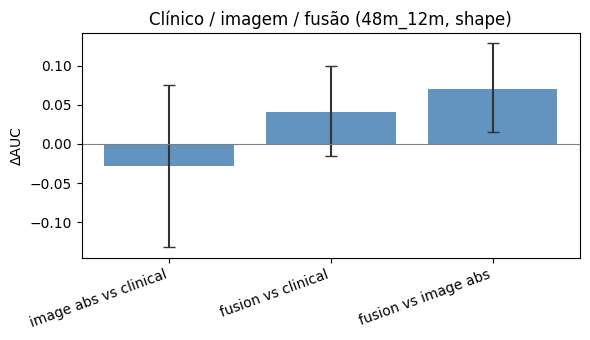

In [10]:
cfg = STATS_CFG
base = BASE_CLAIM  # clinic/fusion só em 48m_12m
mod = CLINIC_MODALITY  # shape: única clinic_img no disco
img_cfg = cfg_for_modality(mod, cfg)
clin_cfg = cfg_clinical(cfg)
fusion_path = fusion_results_path(
    base, mod, selection_mode=cfg.selection_mode, with_combat=cfg.with_combat,
)
clin_path = clinical_results_path(base)
img_path = image_ablation_path(base, "abs", mod)

clinical_rows: list[dict] = []
if img_path.exists() and clin_path.exists():
    paired = patient_scores_from_path(img_path, img_cfg).merge(
        patient_scores_from_path(clin_path, clin_cfg),
        on=["ID_PT", "y"],
        suffixes=("_img", "_clin"),
    )
    row = paired_comparison_row(
        paired,
        score_a="score_img",
        score_b="score_clin",
        label_a="img",
        label_b="clin",
        n_boot=cfg.n_bootstrap,
        seed=cfg.seed + 200,
        permutation_auc_p=permutation_auc_p,
        n_perm=cfg.n_perm,
        alpha=ALPHA,
    )
    row.update({"modality": mod, "comparison": "image_abs_vs_clinical"})
    clinical_rows.append(row)

if fusion_path.exists() and clin_path.exists():
    paired = patient_scores_from_path(fusion_path, img_cfg).merge(
        patient_scores_from_path(clin_path, clin_cfg),
        on=["ID_PT", "y"],
        suffixes=("_fusion", "_clin"),
    )
    row = paired_comparison_row(
        paired,
        score_a="score_fusion",
        score_b="score_clin",
        label_a="fusion",
        label_b="clin",
        n_boot=cfg.n_bootstrap,
        seed=cfg.seed + 201,
        permutation_auc_p=permutation_auc_p,
        n_perm=cfg.n_perm,
        alpha=ALPHA,
    )
    row.update({"modality": mod, "comparison": "fusion_vs_clinical"})
    clinical_rows.append(row)

if fusion_path.exists() and img_path.exists():
    paired = patient_scores_from_path(fusion_path, img_cfg).merge(
        patient_scores_from_path(img_path, img_cfg),
        on=["ID_PT", "y"],
        suffixes=("_fusion", "_img"),
    )
    row = paired_comparison_row(
        paired,
        score_a="score_fusion",
        score_b="score_img",
        label_a="fusion",
        label_b="img",
        n_boot=cfg.n_bootstrap,
        seed=cfg.seed + 202,
        permutation_auc_p=permutation_auc_p,
        n_perm=cfg.n_perm,
        alpha=ALPHA,
    )
    row.update({"modality": mod, "comparison": "fusion_vs_image_abs"})
    clinical_rows.append(row)

cmp_clinical = pd.DataFrame(clinical_rows)
if not cmp_clinical.empty:
    cmp_clinical["p_fdr_bh"] = apply_bh_fdr(cmp_clinical["p_bootstrap_one_sided"].to_numpy())
    cmp_clinical["significant_fdr"] = (
        cmp_clinical["p_fdr_bh"] < ALPHA
    ) & (cmp_clinical["ci95_lo"] > 0)

print(f"Clínico / imagem / fusão | {base.name} | {cfg.task} | mod={mod} | {cfg.model_key}\n")
if clin_path.exists():
    display(cmp_clinical.round(4) if not cmp_clinical.empty else "sem pares")
else:
    print(f"MISSING {clin_path} — pular §5")

print("\n── Interpretação ──")
for _, r in cmp_clinical.iterrows():
    print(
        f"  {r['comparison']}: ΔAUC={r['delta_auc']:.3f} "
        f"[{r['ci95_lo']:.3f}, {r['ci95_hi']:.3f}]  p={r['p_bootstrap_one_sided']:.4f}"
    )

if not cmp_clinical.empty:
    fig, ax = plt.subplots(figsize=(6, 3.5))
    labels = cmp_clinical["comparison"].str.replace("_", " ", regex=False)
    x = np.arange(len(cmp_clinical))
    ax.bar(x, cmp_clinical["delta_auc"], color="steelblue", alpha=0.85)
    ax.errorbar(
        x,
        cmp_clinical["delta_auc"],
        yerr=[
            cmp_clinical["delta_auc"] - cmp_clinical["ci95_lo"],
            cmp_clinical["ci95_hi"] - cmp_clinical["delta_auc"],
        ],
        fmt="none",
        color="0.2",
        capsize=4,
    )

    ax.axhline(0, color="0.5", lw=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=20, ha="right")
    ax.set_ylabel("ΔAUC")
    ax.set_title(f"Clínico / imagem / fusão ({base.name}, {mod})")
    fig.tight_layout()
    plt.show()


## 6. abs vs global / leaky (âncora A · `48m_12m`)

Controlo de leak. Leaky no disco só em `48m_12m` (vol). Mods sem pasta → skip silencioso.


In [11]:
cfg = STATS_CFG
base = BASE_CLAIM  # leaky só em claim

cmp_abs_global = compare_modalities(
    MODS_COMPARE,
    path_a=lambda m: image_ablation_path(BASE_CLAIM, "abs", m),
    path_b=lambda m: image_ablation_path(BASE_CLAIM, "global", m),
    cfg_for_mod=lambda m: cfg_for_modality(m, cfg),
    load_patients=patient_scores_from_path,
    permutation_auc_p=permutation_auc_p,
    n_perm=cfg.n_perm,
    n_bootstrap=cfg.n_bootstrap,
    seed=cfg.seed + 100,
    label_a="abs",
    label_b="global",
    comparison="abs_vs_global",
    alpha=ALPHA,
)
print(f"abs vs global (leaky) | {cfg.task} | {cfg.model_key}\n")
display(cmp_abs_global.round(4))
print("\n── Interpretação (ΔAUC = abs − global; negativo → leaky maior) ──")
print_comparison_summary(cmp_abs_global, label_a="abs", label_b="global")


abs vs global (leaky) | smci_pmci | svm



,n_pacientes,auc_abs,auc_global,delta_auc,ci95_lo,ci95_hi,p_bootstrap_one_sided,p_bootstrap_two_sided,abs_superior,p_perm_abs,p_perm_global,significant_fdr,significant_raw,modality,comparison,p_fdr_bh
0,120,0.6716,0.6782,-0.0067,-0.0298,0.0142,0.7181,0.5639,False,0.0008,0.0004,False,False,vol,abs_vs_global,0.7181



── Interpretação (ΔAUC = abs − global; negativo → leaky maior) ──
  vol: ΔAUC=-0.007 [-0.030, 0.014]  p=0.7181  q=0.7181  → sem evidência
